# Predicting Income Level from U.S. Census Data

**Dataset:** Adult / Census Income (UCI Machine Learning Repository, Kohavi 1996), Kaggle mirror `adult.csv`.

**Goal:** Explore which demographic and employment attributes are associated with earning more than $50,000/year, and compare two classifiers (Logistic Regression, Random Forest) on the prediction task.


## 1. Setup and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv(r"D:\all documents, csv, pdf\adult.csv\adult.csv")
df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 2. Cleaning

Missing values in this dataset are encoded as the string `"?"` rather than `NaN`. We convert and drop them, which is the common approach used in prior work on this dataset.

In [2]:
df = df.replace('?', np.nan)
print('Rows before dropna:', len(df))
df = df.dropna().reset_index(drop=True)
print('Rows after dropna:', len(df))

df['income_binary'] = (df['income'] == '>50K').astype(int)
df['income'].value_counts(normalize=True)


Rows before dropna: 32561
Rows after dropna: 30162


income
<=50K    0.751078
>50K     0.248922
Name: proportion, dtype: float64

## 3. Exploratory data analysis

### Figure 1 — Income by education level

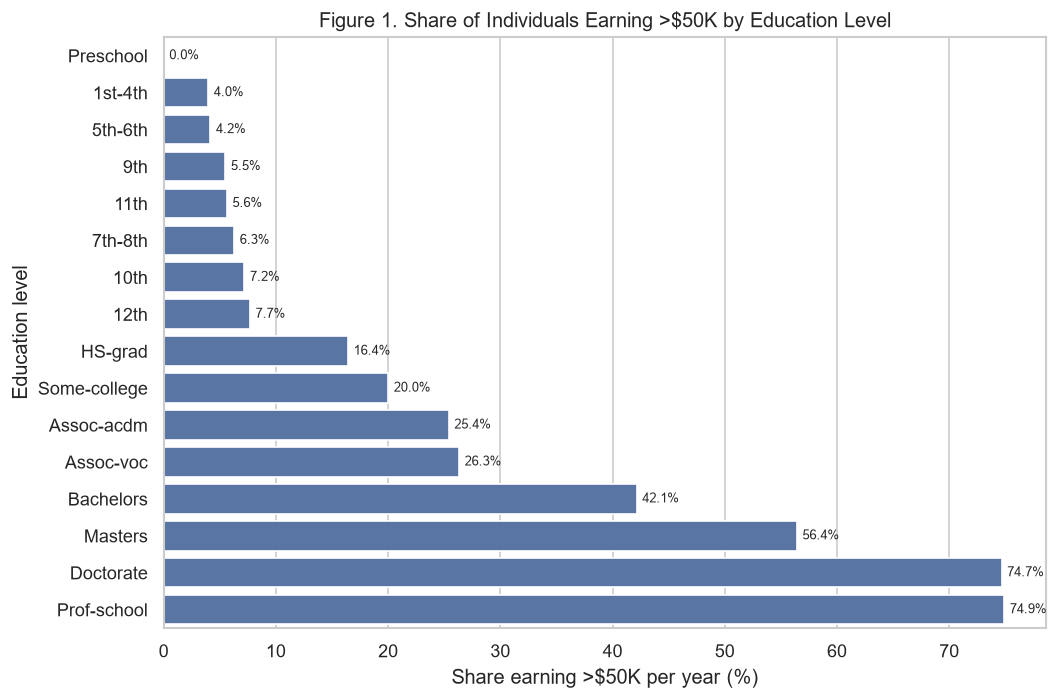

In [ ]:
edu_order = df.groupby('education')['income_binary'].mean().sort_values().index
edu_rate = df.groupby('education')['income_binary'].mean().reindex(edu_order) * 100

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=edu_rate.values, y=edu_rate.index, ax=ax, color='#4C72B0')
ax.set_xlabel('Share earning >$50K per year (%)')
ax.set_ylabel('Education level')
ax.set_title('Figure 1. Share of Individuals Earning >$50K by Education Level')
for i, v in enumerate(edu_rate.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()


### Figure 2 — Age distribution by income class

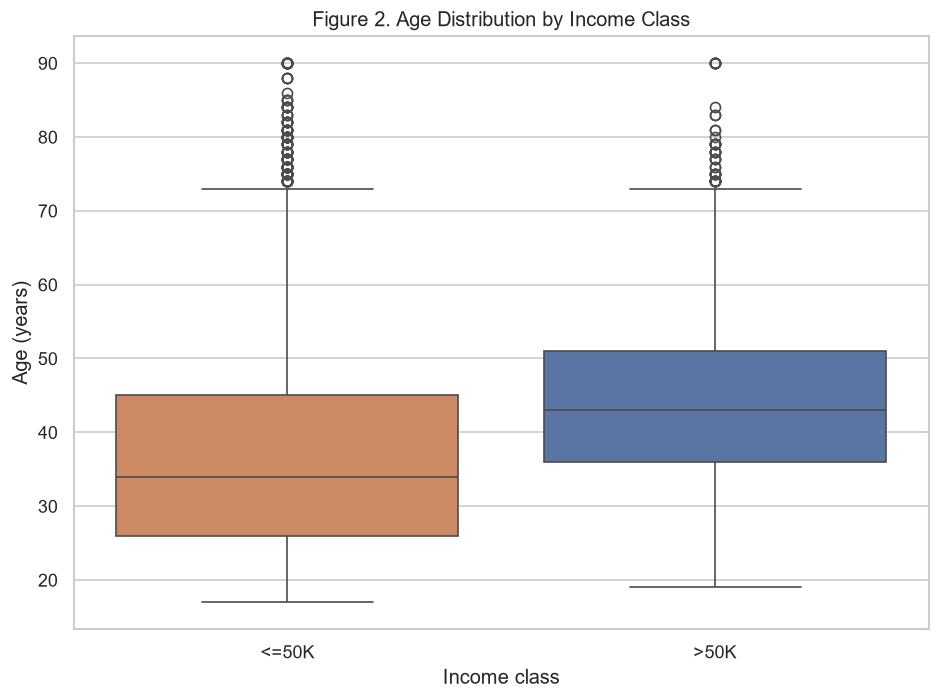

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='income', y='age', hue='income', order=['<=50K', '>50K'],
            palette=['#DD8452', '#4C72B0'], legend=False, ax=ax)
ax.set_xlabel('Income class')
ax.set_ylabel('Age (years)')
ax.set_title('Figure 2. Age Distribution by Income Class')
plt.tight_layout()
plt.show()


### Figure 3 — Weekly hours worked by income class

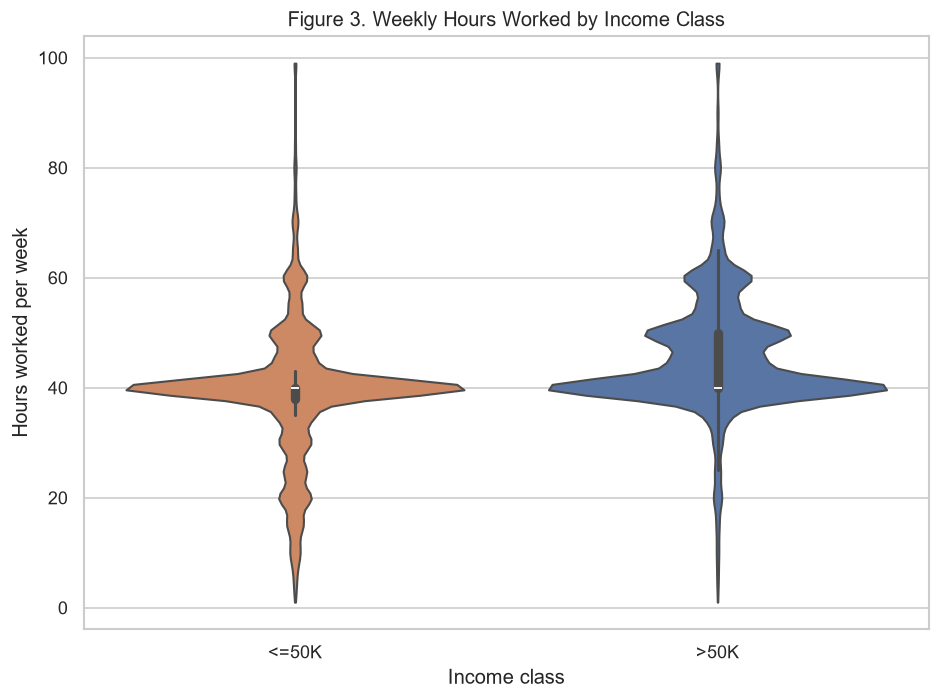

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(data=df, x='income', y='hours.per.week', hue='income', order=['<=50K', '>50K'],
               palette=['#DD8452', '#4C72B0'], legend=False, cut=0, ax=ax)
ax.set_xlabel('Income class')
ax.set_ylabel('Hours worked per week')
ax.set_title('Figure 3. Weekly Hours Worked by Income Class')
plt.tight_layout()
plt.show()


## 4. Modeling

We predict the binary `income_binary` target from the remaining demographic and employment features. `fnlwgt` (a census sampling weight) and the redundant text `education` column (superseded by `education.num`) are dropped. Numeric features are standardized; categorical features are one-hot encoded.

In [7]:
target = 'income_binary'
drop_cols = ['income', 'income_binary', 'fnlwgt', 'education']
X = df.drop(columns=drop_cols)
y = df[target]

numeric_features = ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
categorical_features = ['workclass', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)


(24129, 12) (6033, 12)


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
}

results = []
fitted = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'ROC AUC': roc_auc_score(y_test, proba)
    })
    fitted[name] = pipe

results_df = pd.DataFrame(results).set_index('Model').round(3)
results_df


,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Logistic Regression,0.853,0.751,0.615,0.676,0.913
Random Forest,0.865,0.821,0.585,0.683,0.921


### Figure 4 — Feature importance (Random Forest)

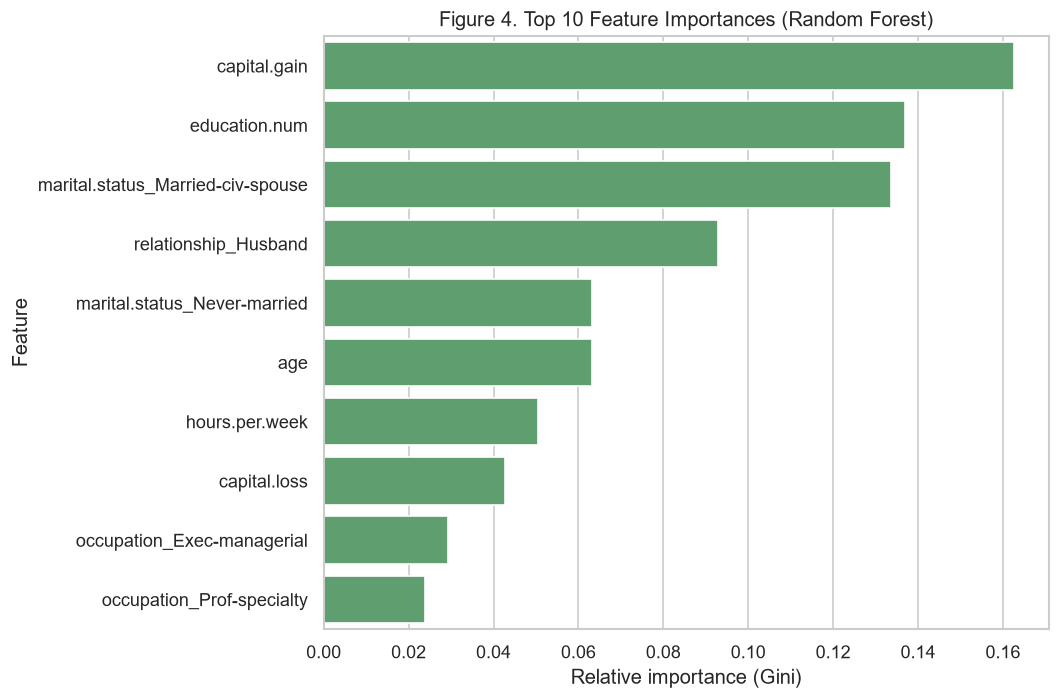

In [ ]:
rf_pipe = fitted['Random Forest']
ohe = rf_pipe.named_steps['prep'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(categorical_features)
all_names = numeric_features + list(cat_names)
importances = rf_pipe.named_steps['clf'].feature_importances_
imp_series = pd.Series(importances, index=all_names).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=imp_series.values, y=imp_series.index, ax=ax, color='#55A868')
ax.set_xlabel('Relative importance (Gini)')
ax.set_ylabel('Feature')
ax.set_title('Figure 4. Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()


## 5. Summary

See `paper.md` in this repository for the full write-up (introduction, methodology, results, discussion, and references) built from this notebook's outputs.